Modified codes from Oadridge group: https://github.com/DrYGuo/EELS-aberration-measurements-and-simulations
Keeping only the EELS aberration image part.

# Initialize

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
# %matplotlib widget

In [4]:
"""Functions for emulating electron optics of a TEM."""


class aberration:
    """A class describing electron lens aberrations."""

    def __init__(self, Krivanek, Haider, Description, amplitude, angle, n, m):
        """
        Intialize the lens aberration object.
        Parameters
        ----------
        Krivanek : str
            A string describing the aberration coefficient in Krivanek notation
            (C_mn)
        Haider : str
            A string describing the aberration coefficient in Haider notation
            (ie. A1, A2, B2)
        Description : str
            A string describing the colloqiual name of the aberration ie. 2-fold
            astig.
        amplitude : float
            The amplitude of the aberration in Angstrom
        angle : float
            The angle of the aberration in radians
        n : int
            The principle aberration order
        m : int
            The rotational order of the aberration.
        """
        self.Krivanek = Krivanek
        self.Haider = Haider
        self.Description = Description
        self.amplitude = amplitude
        self.m = m
        self.n = n
        if m > 0:
            self.angle = angle # This angle is not very consistent with the convention in NION. Here Cnm cos(m*(phi-angle)) is used instead of Cnma cos(m*phi)+Cnmb sin(m*phi)
        else:
            self.angle = 0


    def __str__(self):
        """Return a string describing the aberration."""
        if self.m > 0:
            return (
                "{0:17s} ({1:2s}) -- {2:3s} = {3:9.2e} \u00E5 \u03B8 = "
                + "{4:4d}\u00B0 "
            ).format(
                self.Description,
                self.Haider,
                self.Krivanek,
                self.amplitude,
                int(np.rad2deg(self.angle)),
            )
        else:
            return " {0:17s} ({1:2s}) -- {2:3s} = {3:9.2e} \u00E5".format(
                self.Description, self.Haider, self.Krivanek, self.amplitude
            )
    
# functions below

def aberration_starter_pack():
    """Create the set of aberrations up to fifth order. YG: All the units should be in Angstrom """
    aberrations = []
    aberrations.append(aberration("C10", "C1", "Defocus        ",   0.0, 0.0, 1, 0)) # Cnm_amplitude, Cnm_phase, n, m
    aberrations.append(aberration("C12", "A1", "2-Fold astig.    ", 0.0, 0.0, 1, 2))
    aberrations.append(aberration("C23", "A2", "3-Fold astig.    ", 0.0, 0.0, 2, 3))
    aberrations.append(aberration("C21", "B2", "Axial coma       ", 0.0, 0.0, 2, 1))
    aberrations.append(aberration("C30", "C3", "3rd order spher. ", 0.0, 0.0, 3, 0))
    aberrations.append(aberration("C34", "A3", "4-Fold astig.    ", 0.0, 0.0, 3, 4))
    aberrations.append(aberration("C32", "S3", "Axial star aber. ", 0.0, 0.0, 3, 2))
    aberrations.append(aberration("C45", "A4", "5-Fold astig.    ", 0.0, 0.0, 4, 5))
    aberrations.append(aberration("C43", "D4", "3-Lobe aberr.    ", 0.0, 0.0, 4, 3))
    aberrations.append(aberration("C41", "B4", "4th order coma   ", 0.0, 0.0, 4, 1))
    aberrations.append(aberration("C50", "C5", "5th order spher. ", 0.0, 0.0, 5, 0))
    aberrations.append(aberration("C56", "A5", "6-Fold astig.    ", 0.0, 0.0, 5, 6))
    aberrations.append(aberration("C52", "S5", "5th order star   ", 0.0, 0.0, 5, 2))
    aberrations.append(aberration("C54", "R5", "5th order rosette", 0.0, 0.0, 5, 4))
    return aberrations


def q_space_array(pixels, gridsize, meshed=True):
    """
    Return the appropriately scaled 2D reciprocal space coordinates.

    Parameters
    -----------
    pixels : (N,) array_like
        Pixels in each dimension of a ND array
    gridsize : (N,) array_like
        Dimensions of the array in real space units
    meshed : bool, optional
        Option to output dense meshed grid (True) or output unbroadcasted
        arrays (False)

    Parameters
    -----------
    pixels : (N,) array_like
        Pixels in each dimension of a 2D array
    gridsize : (N,) array_like
        Dimensions of the array in real space units
    """
    # N is the dimensionality of grid
    N = len(pixels)

    qspace = [np.fft.fftfreq(pixels[i], d=gridsize[i] / pixels[i]) for i in range(N)]
    # At this point we can return the arrays without broadcasting
    if meshed:
        return broadcast_from_unmeshed(qspace)
    else:
        return qspace
    
def broadcast_from_unmeshed(coords):
    """
    For an unmeshed set of coordinates broadcast to a meshed ND array.

    Examples
    --------
    >>> broadcast_from_unmeshed([np.arange(5),np.arange(6)])
    [array([[0, 0, 0, 0, 0, 0],
       [1, 1, 1, 1, 1, 1],
       [2, 2, 2, 2, 2, 2],
       [3, 3, 3, 3, 3, 3],
       [4, 4, 4, 4, 4, 4]]), array([[0, 1, 2, 3, 4, 5],
       [0, 1, 2, 3, 4, 5],
       [0, 1, 2, 3, 4, 5],
       [0, 1, 2, 3, 4, 5],
       [0, 1, 2, 3, 4, 5]])]
    """

    N = len(coords)
    pixels = [a.shape[0] for a in coords]

    # Broadcasting patterns
    R = np.ones((N, N), dtype=np.int16) + np.diag(pixels) - np.eye(N, dtype=np.int16)

    # Broadcast unmeshed grids
    return [np.broadcast_to(a.reshape(rr), pixels) for a, rr in zip(coords, R)]

def chi(q, qphi, lam, df=0.0, aberrations=[]):
    r"""
    Calculate the aberration function, chi.
    Parameters
    ----------
    q : float or array_like
        Reciprocal space extent (Inverse angstroms).
    qphi : float or array_like
        Azimuth of grid in radians
    lam : float
        Wavelength of electron (Inverse angstroms).
    df : float, optional
        Defocus in Angstrom
    aberrations : list, optional
        A list containing a set of the class aberration, pass an empty list for
        an unaberrated contrast transfer function.
    Returns
    -------
    chi : float or array_like
        The aberration function, will be the same shape as `q`. This is used to
        calculate the probe wave function in reciprocal space.
    """
    qlam = q * lam
    chi_ = qlam ** 2 / 2 * df
    for ab in aberrations:
        chi_ += (
            qlam ** (ab.n + 1)
            * float(ab.amplitude)
            / (ab.n + 1)
            * np.cos(ab.m * (qphi - float(ab.angle)))
        )
    return 2 * np.pi * chi_ / lam

def make_contrast_transfer_function(
    pix_dim,
    real_dim,
    eV,
    app,
    optic_axis=[0, 0],
    aperture_shift=[0, 0],
    tilt_units="mrad",
    df=0,
    aberrations=[],
    q=None,
    app_units="mrad",
):
    """
    Make an electron lens contrast transfer function.
    Parameters
    ---------
    pix_dim : (2,) int array_like
        The pixel size of the grid
    real_dim : (2,) float array_like
        The size of the grid in Angstrom
    eV : float
        The energy of the probe electrons in eV
    app : float or None
        The aperture in units specified by app_units, pass `app` = None for
        no aperture
    optic_axis : (2,) array_like, optional
        allows the user to specify a different optic axis in units specified by
        `tilt_units`
    aperture_shift : (2,) array_like, optional
        Shift of the objective aperture relative to the center of the array
    tilt_units : string
        Units of the `optic_axis` or `aperture_shift` values, default is mrad
    df : float
        Probe defocus in A, a negative value indicate overfocus
    aberrations : array_like of aberration objects
        List containing instances of class aberration
    q :
        Precomputed reciprocal space array, allows the user to reduce
        computation time somewhat
    app_units : string
        The units of `app` (A^-1 or mrad)
    Returns
    -------
    ctf : array_like
        The lens contrast transfer function in reciprocal space
    """
    # Make reciprocal space array
    if q is None:
        q = q_space_array(pix_dim, real_dim[:2])

    # Get  electron wave number (inverse of wavelength)
    k = wavev(eV)

    # Convert tilts to units of inverse Angstrom                               
    optic_axis_ = convert_tilt_angles(
        optic_axis, tilt_units, real_dim, eV, invA_out=True
    )
    aperture_shift_ = convert_tilt_angles(
        aperture_shift, tilt_units, real_dim, eV, invA_out=True
    )

    if app is None:
        app_ = np.amax(np.abs(q))
    else:
        # Get aperture size in units of inverse Angstrom
        app_ = convert_tilt_angles(app, app_units, real_dim, eV, invA_out=True)

    # Initialize the array to contain the CTF
    CTF = np.zeros(pix_dim, dtype=complex)

    # Calculate the magnitude of the reciprocal lattice grid
    # qarray1 accounts for a shift of the optic axis
    qarray1 = np.sqrt(
        np.square(q[0] - optic_axis_[0]) + np.square(q[1] - optic_axis_[1])
    )

    # qarray2 accounts for a shift of both the optic axis and the aperture                Is the square root missing?
    qarray2 = np.sqrt(np.square(q[0] - optic_axis_[0] - aperture_shift_[0]) + np.square(                 #  tilt optic axis and shift aperture are equivalent
        q[1] - optic_axis_[1] - aperture_shift_[1]))

    # Calculate azimuth of reciprocal space array in case it is required for
    # aberrations
    qphi = np.arctan2(q[0] - optic_axis_[0], q[1] - optic_axis_[1])

    # Only calculate CTF for region within the aperture
    mask = qarray2 <= app_ 
    plt.imshow(mask)
    print('mask shape')
    print(mask[mask].shape)
    print('normalization constant')
    print(np.count_nonzero(mask))
    plt.colorbar()
    print('qarray2 shape')
    print(qarray2.shape)
    print('masked qarray2 shape')
    print(qarray2[mask].shape)
    print(qarray2[mask].min(),qarray1.min())
    CTF[mask] = np.exp(-1j * chi(qarray2[mask], qphi[mask], 1.0 / k, df, aberrations)) # confused with the sign convention here it seems that the minus sign is consistent with FFT with exp(+i2pix)
    return CTF


def focused_probe(
    gridshape,
    rsize,
    eV,
    app,
    beam_tilt=[0, 0],
    aperture_shift=[0, 0],
    tilt_units="mrad",
    df=0,
    aberrations=[],
    q=None,
    app_units="mrad",
    qspace=False,
):
    """
    Make a focused electron probe wave function.
    Parameters
    ---------
    gridshape : (2,) array_like
        The pixel size of the grid
    rsize : (2,) array_like
        The size of the grid in Angstrom
    eV : float
        The energy of the probe electrons in electron volts
    app : float
        The probe-forming apperture in units specified by app_units, pass None
        if no probe forming aperture is to be used
    beam_tilt : array_like, optional
        Allows the user to simulate a (small < 50 mrad) beam tilt. To maintain
        periodicity of the wave function at the boundaries this tilt is rounded
        to the nearest pixel value.
    aperture_shift : array_like, optional
        Allows the user to simulate a (small < 50 mrad) aperture shift. To
        maintain periodicity of the wave function at the boundaries this tilt
        is rounded to the nearest pixel value.
    tilt_units : string, optional
        Units of beam tilt and aperture shift, can be 'mrad','pixels' or 'invA'
    df : float, optional
        Probe defocus in A, a negative value indicate overfocus
    aberrations : list, optional
        A list of of probe aberrations of class pyms.Probe.aberration, pass an
        empty list for an un-aberrated probe
    app_units : string, optional
        The units of the aperture size ("invA", "pixels" or "mrad")
    qspace : bool, optional
        If True return the probe in reciprocal space
    Returns
    -------
    probe : complex (Y,X) np.ndarray
        The requested electron probe wave function
    """
    probe = make_contrast_transfer_function(
        gridshape,
        rsize,
        eV,
        app,
        beam_tilt,
        aperture_shift,
        tilt_units,
        df,
        aberrations,
        q,
        app_units,
    )

    # Normalize the STEM probe so that its sum-squared intensity is unity
    probe *= np.sqrt(np.prod(gridshape)) / np.sqrt(np.sum(np.square(np.abs(probe))))

    # Return real or diffraction space probe depending on user preference
    if not qspace:
        return np.fft.ifft2(probe)
    return probe


def plane_wave_illumination(
    gridshape, gridsize, eV, tilt=[-10, -10], tilt_units="mrad", qspace=False
):
    """
    Generate plane wave illumination for input to multislice.
    The wave function will be normalized such that sum of intensity is unity in
    real space.
    Parameters
    ----------
    gridshape : (2,) array_like
        Pixel dimensions of the 2D grid
    gridsize : (2,) array_like
        Size of the grid in real space
    eV : float
        Probe energy in electron volts (irrelevant for untilted illumination)
    tilt : array_like, optional
        Allows the user to simulate a (small < 50 mrad) beam tilt, To maintain
        periodicity of the wave function at the boundaries this tilt is rounded
        to the nearest pixel value.
    tilt_units : string, optional
        Units of beam tilt, can be 'mrad','pixels' or 'invA'
    qspace : bool, optional
        Pass qspace = True to get the probe in momentum (q) space
    Returns
    ------
    illum : np.ndarray (Y,X)
    """
    # Initialize array that contains wave function
    illum = np.zeros(gridshape, dtype=np.complex)

    # Convert tilt to units of pixels
    tilt_ = convert_tilt_angles(tilt, tilt_units, gridsize, eV)

    # Case of an untilted plane wave (phase is zero everywhere)
    if tilt[0] == 0 and tilt[1] == 0:
        illum[:, :] = 1 / np.sqrt(np.product(gridshape))

        if qspace:
            return np.fft.fft2(illum)
        else:
            return illum

    # Set the value of wavefunction amplitude such that after inverse Fourier
    # transform (and resulting division by the total number of pixels) the sum
    # of intensity will be 1
    illum[tilt_[0], tilt_[1]] = np.sqrt(np.product(gridshape))

    # Return wave function in real space
    if qspace:
        return illum
    else:
        return np.fft.ifft2(illum)


def wavev(E):
    """
    Evaluate the relativistically corrected wavenumber of an electron with energy E.
    Energy E must be in electron-volts, see Eq. (2.5) in Kirkland's Advanced
    Computing in electron microscopy
    """
    # Planck's constant times speed of light in eV Angstrom
    hc = 1.23984193e4
    # Electron rest mass in eV
    m0c2 = 5.109989461e5
    return np.sqrt(E * (E + 2 * m0c2)) / hc


def relativistic_mass_correction(E):
    """
    Evaluate the relativistic mass correction for electron with energy E in eV.
    See Eq. (2.2) in Kirkland's Advanced Computing in electron microscopy.
    """
    # Electron rest mass in eV
    m0c2 = 5.109989461e5
    return (m0c2 + E) / m0c2


def convert_tilt_angles(tilt, tilt_units, rsize, eV, invA_out=False):
    """
    Convert  tilt to pixel or inverse Angstroms units regardless of input units.
    Input units can be mrad, pixels or inverse Angstrom
    Parameters
    ----------
    tilt : array_like
        Tilt in units of mrad, pixels or inverse Angstrom
    tilt_units : string
        Units of specimen and beam tilt, can be 'mrad','pixels' or 'invA'
    rsize : (2,) array_like
        The size of the grid in Angstrom
    eV : float
        Probe energy in electron volts
    invA_out : bool
        Pass True if inverse Angstrom units are desired.
    """
    # If units of the tilt are given in mrad, convert to inverse Angstrom
    if tilt_units == "mrad":
        k = wavev(eV)
        tilt_ = np.asarray(tilt) * 1e-3 * k
    else:
        tilt_ = tilt

    # If inverse Angstroms are requested our work here is done
    if invA_out:
        return tilt_

    # Convert inverse Angstrom to pixel coordinates, this will be rounded
    # to the nearest pixel
    if tilt_units != "pixels":
        tilt_ = np.round(tilt_ * rsize[:2]).astype(int)
    return tilt_

In [5]:
chi_result=chi(0.01,0.01,0.0025,1,aberrations=aberration_starter_pack())
print(chi_result)

7.853981633974482e-07


mask shape
(3125,)
normalization constant
3125
qarray2 shape
(256, 256)
masked qarray2 shape
(3125,)
0.0 0.0


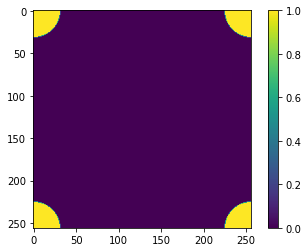

In [6]:
Transfer_function=make_contrast_transfer_function(pix_dim=[256,256],real_dim=[51.2,51.2],eV=6e4,app=30,optic_axis=[0,0],aperture_shift=[0,0],tilt_units='mrad',df=0,aberrations=aberration_starter_pack(),q=None,app_units='mrad')


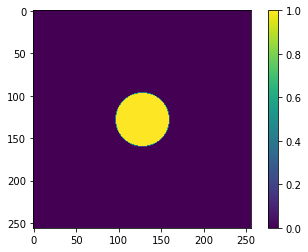

In [7]:
Transfer_function_shift=np.fft.fftshift(Transfer_function)
#Transfer_function_shift.shape
#Transfer_function.shape
#print(Transfer_function)
plt.imshow(abs(Transfer_function_shift))
plt.colorbar()

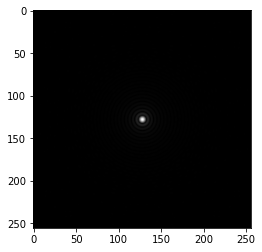

In [8]:
plt.set_cmap('gray')
Transfer_function_real=np.fft.fftshift(np.fft.ifft2(Transfer_function))
plt.imshow(abs(Transfer_function_real))

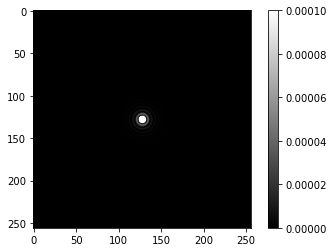

In [14]:
I_real=Transfer_function_real*np.conjugate(Transfer_function_real)
plt.imshow(abs(I_real),vmax=0.0001)
plt.colorbar()

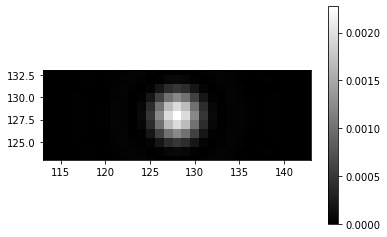

In [20]:
I_real=Transfer_function_real*np.conjugate(Transfer_function_real)
plt.imshow(abs(I_real))
# plot x y only to the extend where the intensity is not negligible (0.1% of max intensity).
plt.xlim(np.where(abs(I_real) > 0.001 * abs(I_real).max())[0][0], np.where(abs(I_real) > 0.001 * abs(I_real).max())[0][-1])
plt.ylim(np.where(abs(I_real) > 0.001 * abs(I_real).max())[1][0], np.where(abs(I_real) > 0.001 * abs(I_real).max())[1][-1])
plt.colorbar()
plt.show()

# To calculate the EELS, just Fourier transform the contrast transfer function into real space in one dimension
See projection-slice theorem from https://en.wikipedia.org/wiki/Projection-slice_theorem

For EELS, the chi function needs to be re-written

In [6]:
def chi_2(q,lam,df=0,aberrations=[]):

    '''
    In this notation, qlam is a vector, qlam[1] is in x direction (dispersive direction) and qlam[0] is in y direction
    '''

     # qlam is just theta
    x=q[1]*lam # x means thetax
    y=q[0]*lam

    chi_=0 #initialize with some defocus

    for n in range(6):
        for m in range(6):
            chi_+= aberrations[n][m]/(n+1)*x**(n+1)*y**m

    # chi_=chi_+(E10/2)*x**2 + E01 *x*y +(E20/3) *x**3 + (E11/2)* x**2 *y + E02* x* y**2 \
    # + (E30/4)* x**4 + (E12/2)* x**2*y**2 + (E21/3)*x**3*y + E03* x* y**3 \
    # + (E40/5)* x**5 + (E31/4)* x**4*y**1 + (E22/3)*x**3*y**2 + (E13/2)* x**2*y**3 + E04* x*y**4

    return 2 * np.pi * chi_ /lam  



def make_contrast_transfer_function_2(
    pix_dim,
    real_dim,
    eV,
    app,
    optic_axis=[0, 0],
    aperture_shift=[0, 0],
    tilt_units="mrad",
    df=0,
    aberrations=[],
    q=None,
    app_units="mrad",
):
    """
    Make an electron lens contrast transfer function.
    Parameters
    ---------
    pix_dim : (2,) int array_like
        The pixel size of the grid
    real_dim : (2,) float array_like
        The size of the grid in Angstrom
    eV : float
        The energy of the probe electrons in eV
    app : float or None
        The aperture in units specified by app_units, pass `app` = None for
        no aperture
    optic_axis : (2,) array_like, optional
        allows the user to specify a different optic axis in units specified by
        `tilt_units`
    aperture_shift : (2,) array_like, optional
        Shift of the objective aperture relative to the center of the array
    tilt_units : string
        Units of the `optic_axis` or `aperture_shift` values, default is mrad
    df : float
        Probe defocus in A, a negative value indicate overfocus
    aberrations : array_like of aberration specific for EELS
        List containing values of Enm
    q :
        Precomputed reciprocal space array, allows the user to reduce
        computation time somewhat
    app_units : string
        The units of `app` (A^-1 or mrad)
    Returns
    -------
    ctf : array_like
        The lens contrast transfer function in reciprocal space
    """
    # Make reciprocal space array
    if q is None:
        q = q_space_array(pix_dim, real_dim[:2])

    # Get  electron wave number (inverse of wavelength)
    k = wavev(eV)

    # Convert tilts to units of inverse Angstrom                               
    optic_axis_ = convert_tilt_angles(
        optic_axis, tilt_units, real_dim, eV, invA_out=True
    )
    aperture_shift_ = convert_tilt_angles(
        aperture_shift, tilt_units, real_dim, eV, invA_out=True
    )

    if app is None:
        app_ = np.amax(np.abs(q))
    else:
        # Get aperture size in units of inverse Angstrom
        app_ = convert_tilt_angles(app, app_units, real_dim, eV, invA_out=True)

    # Initialize the array to contain the CTF
    CTF = np.zeros(pix_dim, dtype=complex)

    # Calculate the magnitude of the reciprocal lattice grid
    # qarray1 accounts for a shift of the optic axis
    qarray1 = np.sqrt(
        np.square(q[0] - optic_axis_[0]) + np.square(q[1] - optic_axis_[1])
    )

    # qarray2 accounts for a shift of both the optic axis and the aperture                Is the square root missing?
    qarray2 = np.sqrt(np.square(q[0] - optic_axis_[0] - aperture_shift_[0]) + np.square(                 #  tilt optic axis and shift aperture are equivalent
        q[1] - optic_axis_[1] - aperture_shift_[1]))

    # Calculate azimuth of reciprocal space array in case it is required for
    # aberrations
    qphi = np.arctan2(q[0] - optic_axis_[0], q[1] - optic_axis_[1])

    # Only calculate CTF for region within the aperture
    mask = qarray2 <= app_ 
    
    # print(q[0].shape)

    # print(mask)

    # print('normalization constant')
    # print(np.count_nonzero(mask))

    # print('qarray shape')
    # print(qarray1.shape)
    # print(np.array(q[0][mask]).shape)

    # print(np.where(mask2==1)[1][:].shape)
    # print('what is up')
    CTF[mask] = np.exp(-1j *chi_2([np.array(q[0][mask]),np.array(q[1][mask])],1.0/k,0,aberrations)) # confused with the sign convention here it seems that the minus sign is consistent with FFT with exp(+i2pix)
    # print(CTF.shape)
    return CTF

#print(chi_2([0.01,0.01],0.0002,df=0))

In [7]:
# Create a 6x6 list filled with zeros
Enm = [[0 for _ in range(6)] for _ in range(6)]

Enm[0][1] = 0e1

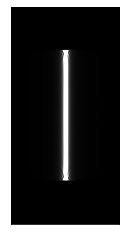

In [8]:
#Transfer_function=make_contrast_transfer_function_2(pix_dim=[256,256],real_dim=[51.2,51.2],eV=30e3,app=40,optic_axis=[0,0],aperture_shift=[0,0],tilt_units='mrad',df=0,aberrations=Enm,q=None,app_units='mrad')
Transfer_function=make_contrast_transfer_function_2(pix_dim=[512,256],real_dim=[128,64],eV=80e3,app=50,optic_axis=[0,0],aperture_shift=[0,0],tilt_units='mrad', df=0, aberrations=Enm, q=None, app_units='mrad')
Transfer_function_shift=np.fft.fftshift(Transfer_function)
EELS_Transfer_function_real=np.fft.fftshift(np.fft.fft(Transfer_function,axis=-1)) # although this should be a Forward FFT, the sign convention tries to follow Kirkland's book which has the opposite sign for FFT in numpy
I_EELS_real= abs(EELS_Transfer_function_real*np.conjugate(EELS_Transfer_function_real)) # can be dived by the 

fig, ax = plt.subplots()
norm = Normalize(vmin=0, vmax=np.percentile(I_EELS_real, 98))
cax = ax.imshow(I_EELS_real, cmap='gray', norm=norm)
ax.set_xticks([])
ax.set_yticks([])
plt.show()
#plt.colorbar()